In [2]:
import pandas as pd
import numpy as np
import os
import warnings

os.environ["OMP_NUM_THREADS"] = "5"
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/student_stress_dataset.csv")

In [4]:
features = [
    "anxiety_level",
    "depression",
    "sleep_quality",
    "study_load",
    "peer_pressure",
    "social_support",
    "academic_performance",
    "future_career_concerns"
]

X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

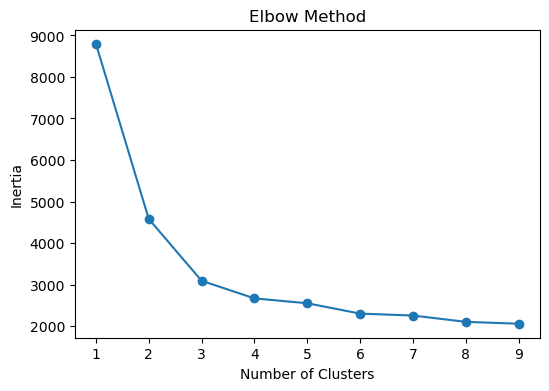

In [5]:
inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)

df["cluster"] = kmeans.fit_predict(X_scaled)

df["cluster"].value_counts()

cluster
0    474
1    325
2    301
Name: count, dtype: int64

In [7]:
cluster_summary = df.groupby("cluster")[features].mean()
cluster_summary

,anxiety_level,depression,sleep_quality,study_load,peer_pressure,social_support,academic_performance,future_career_concerns
cluster,,,,,,,,
0,10.881857,11.945148,2.620253,2.424051,2.329114,1.799578,2.516878,2.489451
1,17.704615,21.276923,1.030769,3.953846,4.452308,0.972308,1.541538,4.412308
2,4.179402,4.099668,4.481728,1.495017,1.518272,2.993355,4.504983,0.996678


In [8]:
cluster_labels = {
    0: "Academic Pressure",
    1: "High Stress",
    2: "Balanced Students"
}

df["cluster_label"] = df["cluster"].map(cluster_labels)

df[["cluster","cluster_label"]].head()

,cluster,cluster_label
0,0,Academic Pressure
1,1,High Stress
2,0,Academic Pressure
3,1,High Stress
4,0,Academic Pressure


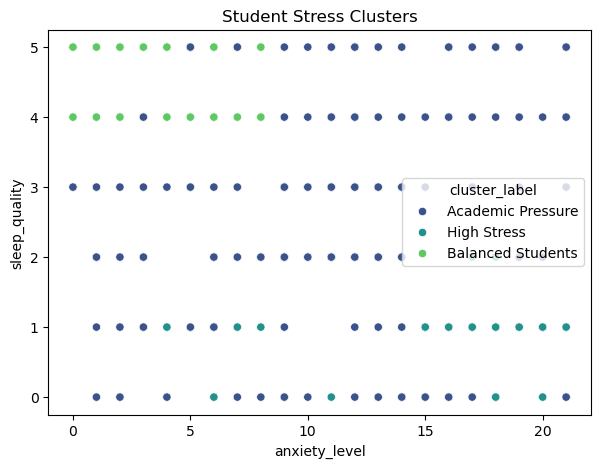

In [9]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["anxiety_level"],
    y=df["sleep_quality"],
    hue=df["cluster_label"],
    palette="viridis"
)

plt.title("Student Stress Clusters")
plt.show()

In [10]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df["cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.4385038156594458


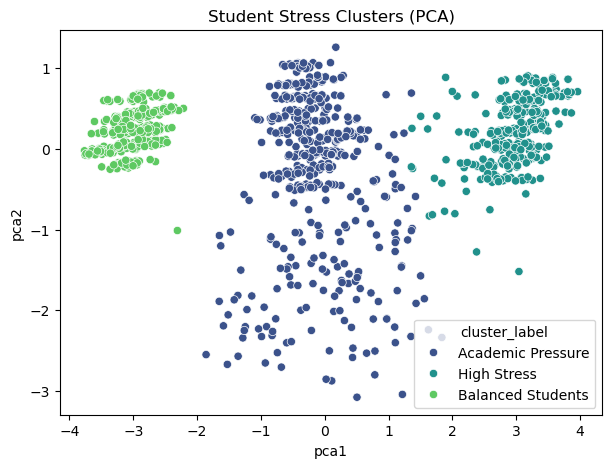

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["pca1"] = X_pca[:,0]
df["pca2"] = X_pca[:,1]

plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["pca1"],
    y=df["pca2"],
    hue=df["cluster_label"],
    palette="viridis"
)

plt.title("Student Stress Clusters (PCA)")
plt.show()

In [13]:
import joblib

joblib.dump(kmeans, "../models/student_cluster_model.pkl")
joblib.dump(scaler, "../models/cluster_scaler.pkl")
joblib.dump(features, "../models/cluster_features.pkl")

['../models/cluster_features.pkl']